# Water Tower Network: Linear Systems Analysis

## City Layout & Physical Story

A city has three water towers (A, B, C) that supply water to different districts. The towers are interconnected and also supply water directly to the city. We want to find the flow rates at each tower to meet demand.

### Physical Setup
- **Tower A**: Connected to the city and to Tower B
- **Tower B**: Connected to the city, Tower A, and Tower C  
- **Tower C**: Connected to the city and to Tower B

The flow balance equations at each tower give us a system of linear equations.

In [1]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

## Gauss-Seidel Method Implementation

The Gauss-Seidel method is an iterative technique for solving systems of linear equations. It updates each variable using the most recent values available.

In [2]:
def gauss_seidel(A, b, x0=None, tol=1e-6, max_iter=100, verbose=False):
    """
    Solve Ax = b using Gauss-Seidel iteration.
    
    Parameters:
    -----------
    A : ndarray
        Coefficient matrix
    b : ndarray
        Right-hand side vector
    x0 : ndarray, optional
        Initial guess (defaults to zeros)
    tol : float
        Convergence tolerance
    max_iter : int
        Maximum number of iterations
    verbose : bool
        Print iteration details
    
    Returns:
    --------
    x : ndarray
        Solution vector
    history : list
        Iteration history [(iteration, x_values, error), ...]
    converged : bool
        Whether the method converged
    """
    n = len(b)
    x = x0.copy() if x0 is not None else np.zeros(n)
    history = [(0, x.copy(), np.inf)]
    
    for k in range(1, max_iter + 1):
        x_old = x.copy()
        
        for i in range(n):
            if abs(A[i, i]) < 1e-12:
                if verbose:
                    print(f"Warning: Near-zero diagonal element at row {i}")
                # Skip update for this variable to avoid division by zero
                continue
            
            sigma = 0
            for j in range(n):
                if j != i:
                    sigma += A[i, j] * x[j]
            x[i] = (b[i] - sigma) / A[i, i]
        
        error = la.norm(x - x_old, ord=np.inf)
        history.append((k, x.copy(), error))
        
        if verbose:
            print(f"Iter {k}: x = {x}, error = {error:.2e}")
        
        if error < tol:
            return x, history, True
    
    return x, history, False

---
## Case 1: Good System (Well-Conditioned)

### Physical Interpretation
All three towers are connected to the city and to each other. The coefficient matrix is diagonally dominant, ensuring Gauss-Seidel convergence.

**Flow equations:**
- Tower A: 4A - B - C = 100 (supplies 100 units to city)
- Tower B: -A + 4B - C = 150 (supplies 150 units to city)
- Tower C: -A - B + 4C = 200 (supplies 200 units to city)

In [3]:
# Good case: Diagonally dominant matrix
A_good = np.array([
    [4, -1, -1],
    [-1, 4, -1],
    [-1, -1, 4]
], dtype=float)

b_good = np.array([100, 150, 200], dtype=float)

print("Coefficient Matrix A:")
print(A_good)
print("\nRHS Vector b:")
print(b_good)

Coefficient Matrix A:
[[ 4. -1. -1.]
 [-1.  4. -1.]
 [-1. -1.  4.]]

RHS Vector b:
[100. 150. 200.]


In [4]:
# Check matrix properties
print("Matrix Properties:")
print(f"Determinant: {la.det(A_good):.4f}")
print(f"Condition number: {la.cond(A_good):.4f}")

# Check diagonal dominance
is_diag_dominant = True
for i in range(len(A_good)):
    diag = abs(A_good[i, i])
    off_diag_sum = sum(abs(A_good[i, j]) for j in range(len(A_good)) if j != i)
    if diag <= off_diag_sum:
        is_diag_dominant = False
    print(f"Row {i}: |{A_good[i,i]}| vs {off_diag_sum} -> {'OK' if diag > off_diag_sum else 'NOT dominant'}")

print(f"\nDiagonally dominant: {is_diag_dominant}")

Matrix Properties:
Determinant: 50.0000
Condition number: 2.5000
Row 0: |4.0| vs 2.0 -> OK
Row 1: |4.0| vs 2.0 -> OK
Row 2: |4.0| vs 2.0 -> OK

Diagonally dominant: True


### Solution using numpy.linalg.solve

In [5]:
# Direct solution
x_direct = la.solve(A_good, b_good)
print("Direct Solution (linalg.solve):")
print(f"Tower A flow: {x_direct[0]:.6f}")
print(f"Tower B flow: {x_direct[1]:.6f}")
print(f"Tower C flow: {x_direct[2]:.6f}")

# Verify solution
residual = la.norm(A_good @ x_direct - b_good)
print(f"\nResidual ||Ax - b||: {residual:.2e}")

Direct Solution (linalg.solve):
Tower A flow: 65.000000
Tower B flow: 75.000000
Tower C flow: 85.000000

Residual ||Ax - b||: 5.86e-14


### Solution using Gauss-Seidel

In [6]:
# Gauss-Seidel solution
x0 = np.zeros(3)
x_gs, history, converged = gauss_seidel(A_good, b_good, x0, tol=1e-6, max_iter=50, verbose=True)

print(f"\nConverged: {converged}")
print(f"\nGauss-Seidel Solution:")
print(f"Tower A flow: {x_gs[0]:.6f}")
print(f"Tower B flow: {x_gs[1]:.6f}")
print(f"Tower C flow: {x_gs[2]:.6f}")

Iter 1: x = [25.     43.75   67.1875], error = 6.72e+01
Iter 2: x = [52.734375   67.48046875 80.05371094], error = 2.77e+01
Iter 3: x = [61.88354492 72.98431396 83.71696472], error = 9.15e+00
Iter 4: x = [64.17531967 74.4730711  84.66209769], error = 2.29e+00
Iter 5: x = [64.7837922  74.86147247 84.91131617], error = 6.08e-01
Iter 6: x = [64.94319716 74.96362833 84.97670637], error = 1.59e-01
Iter 7: x = [64.98508368 74.99044751 84.9938828 ], error = 4.19e-02
Iter 8: x = [64.99608258 74.99749134 84.99839348], error = 1.10e-02
Iter 9: x = [64.99897121 74.99934117 84.99957809], error = 2.89e-03
Iter 10: x = [64.99972982 74.99982698 84.9998892 ], error = 7.59e-04
Iter 11: x = [64.99992904 74.99995456 84.9999709 ], error = 1.99e-04
Iter 12: x = [64.99998137 74.99998807 84.99999236], error = 5.23e-05
Iter 13: x = [64.99999511 74.99999687 84.99999799], error = 1.37e-05
Iter 14: x = [64.99999871 74.99999918 84.99999947], error = 3.61e-06
Iter 15: x = [64.99999966 74.99999978 84.99999986], err

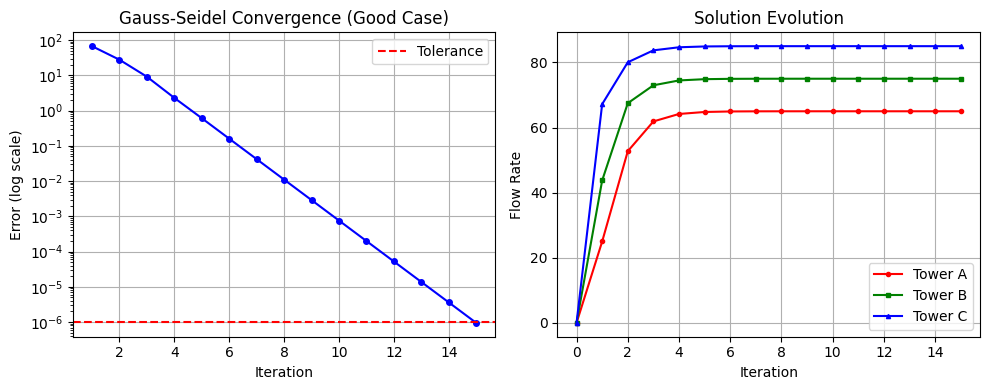

In [7]:
# Plot convergence
iterations = [h[0] for h in history[1:]]  # Skip initial
errors = [h[2] for h in history[1:]]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.semilogy(iterations, errors, 'b-o', markersize=4)
plt.axhline(y=1e-6, color='r', linestyle='--', label='Tolerance')
plt.xlabel('Iteration')
plt.ylabel('Error (log scale)')
plt.title('Gauss-Seidel Convergence (Good Case)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
x_history = np.array([h[1] for h in history])
plt.plot(range(len(history)), x_history[:, 0], 'r-o', label='Tower A', markersize=3)
plt.plot(range(len(history)), x_history[:, 1], 'g-s', label='Tower B', markersize=3)
plt.plot(range(len(history)), x_history[:, 2], 'b-^', label='Tower C', markersize=3)
plt.xlabel('Iteration')
plt.ylabel('Flow Rate')
plt.title('Solution Evolution')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [8]:
# Iteration table
print("\nGauss-Seidel Iteration Table:")
print("-" * 70)
print(f"{'Iter':>4} | {'Tower A':>12} | {'Tower B':>12} | {'Tower C':>12} | {'Error':>12}")
print("-" * 70)
for k, x, err in history:
    if k <= 10 or k == len(history) - 1:
        err_str = f"{err:.2e}" if err != np.inf else "---"
        print(f"{k:>4} | {x[0]:>12.6f} | {x[1]:>12.6f} | {x[2]:>12.6f} | {err_str:>12}")
print("-" * 70)


Gauss-Seidel Iteration Table:
----------------------------------------------------------------------
Iter |      Tower A |      Tower B |      Tower C |        Error
----------------------------------------------------------------------
   0 |     0.000000 |     0.000000 |     0.000000 |          ---
   1 |    25.000000 |    43.750000 |    67.187500 |     6.72e+01
   2 |    52.734375 |    67.480469 |    80.053711 |     2.77e+01
   3 |    61.883545 |    72.984314 |    83.716965 |     9.15e+00
   4 |    64.175320 |    74.473071 |    84.662098 |     2.29e+00
   5 |    64.783792 |    74.861472 |    84.911316 |     6.08e-01
   6 |    64.943197 |    74.963628 |    84.976706 |     1.59e-01
   7 |    64.985084 |    74.990448 |    84.993883 |     4.19e-02
   8 |    64.996083 |    74.997491 |    84.998393 |     1.10e-02
   9 |    64.998971 |    74.999341 |    84.999578 |     2.89e-03
  10 |    64.999730 |    74.999827 |    84.999889 |     7.59e-04
  15 |    65.000000 |    75.000000 |    85.0000

---
## Case 2: Singular System (Ring Topology - No Unique Solution)

### Physical Interpretation
The towers form a ring network where each tower only connects to its neighbors. This creates dependent equations - the system has infinitely many solutions.

**Flow equations (ring topology):**
- Tower A: A - B = 0 (A sends to B)
- Tower B: B - C = 0 (B sends to C)
- Tower C: C - A = 0 (C sends to A)

These equations are dependent: if A = B and B = C and C = A, any value works!

In [9]:
# Singular case: Ring topology (dependent equations)
A_singular = np.array([
    [1, -1, 0],
    [0, 1, -1],
    [-1, 0, 1]
], dtype=float)

b_singular = np.array([0, 0, 0], dtype=float)

print("Coefficient Matrix A (Singular):")
print(A_singular)
print("\nRHS Vector b:")
print(b_singular)

Coefficient Matrix A (Singular):
[[ 1. -1.  0.]
 [ 0.  1. -1.]
 [-1.  0.  1.]]

RHS Vector b:
[0. 0. 0.]


In [10]:
# Check matrix properties
print("Matrix Properties:")
det = la.det(A_singular)
print(f"Determinant: {det:.6f}")
print(f"Matrix is {'SINGULAR' if abs(det) < 1e-10 else 'non-singular'}")

# Rank
rank = np.linalg.matrix_rank(A_singular)
print(f"Rank: {rank} (full rank would be {len(A_singular)})")

Matrix Properties:
Determinant: 0.000000
Matrix is SINGULAR
Rank: 2 (full rank would be 3)


In [11]:
# Try direct solution - this will fail
print("Attempting linalg.solve on singular matrix...")
try:
    x_direct = la.solve(A_singular, b_singular)
    print(f"Solution: {x_direct}")
    print("Warning: Got a solution but matrix is singular!")
except la.LinAlgError as e:
    print(f"ERROR: {e}")
    print("linalg.solve correctly identifies singular matrix.")

Attempting linalg.solve on singular matrix...
ERROR: Singular matrix
linalg.solve correctly identifies singular matrix.


In [12]:
# Try Gauss-Seidel on singular system
print("\nAttempting Gauss-Seidel on singular matrix...")
x0 = np.array([1.0, 1.0, 1.0])  # Non-zero initial guess
x_gs, history, converged = gauss_seidel(A_singular, b_singular, x0, tol=1e-6, max_iter=20, verbose=True)

print(f"\nConverged: {converged}")
print(f"Final values: {x_gs}")
print("\nNote: Gauss-Seidel may appear to converge but the solution is meaningless.")


Attempting Gauss-Seidel on singular matrix...
Iter 1: x = [1. 1. 1.], error = 0.00e+00

Converged: True
Final values: [1. 1. 1.]

Note: Gauss-Seidel may appear to converge but the solution is meaningless.


---
## Case 3: Broken System (Tower C Isolated but Pumping)

### Physical Interpretation
Tower C is completely isolated (no connection to A or B) but is still trying to pump water. This creates an **inconsistent** system - a zero row in the matrix with non-zero demand.

**Flow equations:**
- Tower A: 4A - B = 100
- Tower B: -A + 4B = 150
- Tower C: 0A + 0B + 0C = 200 (impossible!)

The third equation says 0 = 200, which is impossible.

In [13]:
# Broken case: C isolated but pumping
A_broken = np.array([
    [4, -1, 0],
    [-1, 4, 0],
    [0, 0, 0]    # Zero row - C is isolated
], dtype=float)

b_broken = np.array([100, 150, 200], dtype=float)  # But C still has demand!

print("Coefficient Matrix A (Broken):")
print(A_broken)
print("\nRHS Vector b:")
print(b_broken)
print("\nNote: Row 3 is all zeros but b[2] = 200 (inconsistent!)")

Coefficient Matrix A (Broken):
[[ 4. -1.  0.]
 [-1.  4.  0.]
 [ 0.  0.  0.]]

RHS Vector b:
[100. 150. 200.]

Note: Row 3 is all zeros but b[2] = 200 (inconsistent!)


In [14]:
# Check matrix properties
print("Matrix Properties:")
det = la.det(A_broken)
print(f"Determinant: {det:.6f}")
print(f"Matrix is {'SINGULAR' if abs(det) < 1e-10 else 'non-singular'}")

# Rank analysis
rank_A = np.linalg.matrix_rank(A_broken)
augmented = np.column_stack([A_broken, b_broken])
rank_aug = np.linalg.matrix_rank(augmented)
print(f"\nRank of A: {rank_A}")
print(f"Rank of [A|b]: {rank_aug}")
print(f"\nSystem is {'INCONSISTENT (no solution)' if rank_A != rank_aug else 'consistent'}")

Matrix Properties:
Determinant: 0.000000
Matrix is SINGULAR

Rank of A: 2
Rank of [A|b]: 3

System is INCONSISTENT (no solution)


In [15]:
# Try direct solution - this will fail
print("Attempting linalg.solve on broken matrix...")
try:
    x_direct = la.solve(A_broken, b_broken)
    print(f"Solution: {x_direct}")
except la.LinAlgError as e:
    print(f"ERROR: {e}")
    print("linalg.solve correctly identifies singular matrix.")

Attempting linalg.solve on broken matrix...
ERROR: Singular matrix
linalg.solve correctly identifies singular matrix.


In [16]:
# Watch Gauss-Seidel fail spectacularly
print("\nAttempting Gauss-Seidel on broken matrix...")
print("(Watch it fail due to zero diagonal element)\n")

x0 = np.zeros(3)
x_gs, history, converged = gauss_seidel(A_broken, b_broken, x0, tol=1e-6, max_iter=10, verbose=True)

print(f"\nConverged: {converged}")
print(f"Final values: {x_gs}")
print("\nGauss-Seidel cannot update variable C due to zero diagonal.")
print("The system has no solution - C is isolated but has demand.")


Attempting Gauss-Seidel on broken matrix...
(Watch it fail due to zero diagonal element)

Iter 1: x = [25.   43.75  0.  ], error = 4.38e+01
Iter 2: x = [35.9375   46.484375  0.      ], error = 1.09e+01
Iter 3: x = [36.62109375 46.65527344  0.        ], error = 6.84e-01
Iter 4: x = [36.66381836 46.66595459  0.        ], error = 4.27e-02
Iter 5: x = [36.66648865 46.66662216  0.        ], error = 2.67e-03
Iter 6: x = [36.66665554 46.66666389  0.        ], error = 1.67e-04
Iter 7: x = [36.66666597 46.66666649  0.        ], error = 1.04e-05
Iter 8: x = [36.66666662 46.66666666  0.        ], error = 6.52e-07

Converged: True
Final values: [36.66666662 46.66666666  0.        ]

Gauss-Seidel cannot update variable C due to zero diagonal.
The system has no solution - C is isolated but has demand.


---
## Summary

| Case | Matrix Property | linalg.solve | Gauss-Seidel |
|------|----------------|--------------|---------------|
| Good | Diagonally dominant, det != 0 | Works | Converges |
| Singular | det = 0, rank deficient | Fails (LinAlgError) | May not converge / meaningless |
| Broken (inconsistent) | Zero row, rank(A) != rank([A|b]) | Fails (LinAlgError) | Fails (zero diagonal) |

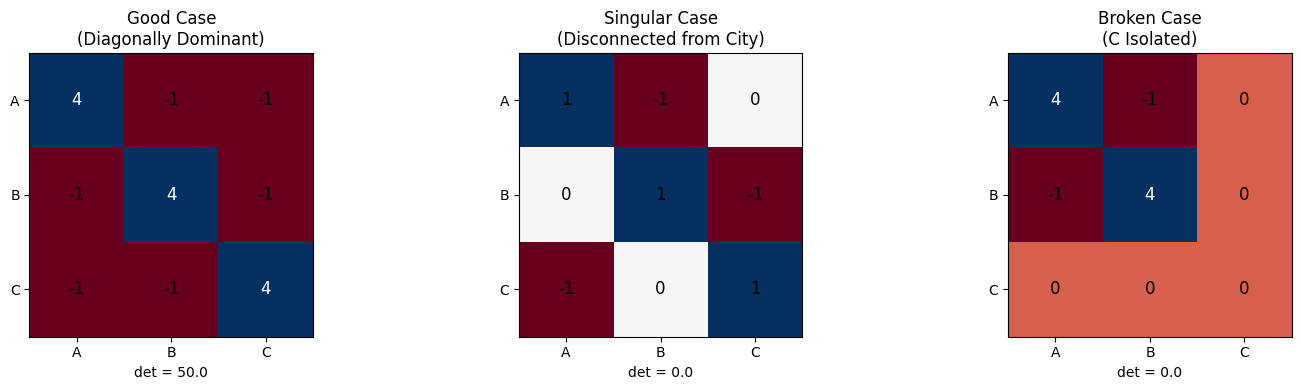

In [17]:
# Visual comparison of all three cases
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matrices = [
    (A_good, "Good Case\n(Diagonally Dominant)"),
    (A_singular, "Singular Case\n(Disconnected from City)"),
    (A_broken, "Broken Case\n(C Isolated)")
]

for ax, (matrix, title) in zip(axes, matrices):
    im = ax.imshow(matrix, cmap='RdBu', aspect='equal')
    ax.set_title(title)
    
    # Add text annotations
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{matrix[i,j]:.0f}', 
                   ha='center', va='center', fontsize=12,
                   color='white' if abs(matrix[i,j]) > 2 else 'black')
    
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(['A', 'B', 'C'])
    ax.set_yticklabels(['A', 'B', 'C'])
    
    det = la.det(matrix)
    ax.set_xlabel(f'det = {det:.1f}')

plt.tight_layout()
plt.show()